# Срочная структура процентных ставок (анализ с помощью динамической копулы)

Данный ноутбук демонстрирует применение многомерных копул с динамическим параметром корреляции к инструменту, сочетающему в себе кредитный риск и рыночный риск процентных ставок.

## Инструмент: Moody's Baa Corporate Bond Yield (DBAA)

В качестве целевого инструмента используется доходность корпоративных облигаций с рейтингом Baa от агенства Moody's. Этот показатель отражает долгосрочные (20–30 лет) корпоративные облигации на нижней границе инвестиционного рейтинга. Доходность складывается из двух компонент:

- Кредитный риск
- Рыночный риск

## Аналитический вопрос

Имея прогноз или субъективное мнение о том, как изменится кривая доходностей государственных облигаций Treasuries (параллельный сдвиг, изменение наклона, изменение кривизны), какое распределение примут изменения DBAA-доходности?

## Методология

1. Данные: DBAA + полная кривая государственных облигаций (7 точек: 1M, 3M, 6M, 1Y, 2Y, 5Y, 10Y)
2. PCA: сокращение кривой до 3 факторов (Level, Slope, Curvature)  
3. Маргинальные распределения: GARCH(1,1)-t для DBAA и каждого PC-фактора
4. PIT: трансформация в U[0,1]
5. DCC t-копула: многомерная копула с динамической матрицей корреляций
6. Условные распределения: аналитическая формула для анализа различных сценариев изменения кривой доходностей

In [50]:
import numpy as np
import pandas as pd
import pandas_datareader.data as web
import scipy.stats as stats
from scipy import special
from scipy.optimize import minimize
from arch import arch_model
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

plt.rcParams['figure.dpi'] = 110

# 1. Загрузка данных

In [51]:
CURVE_TICKERS = ['DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS5', 'DGS10']
MATURITY_LABELS = ['1M', '3M', '6M', '1Y', '2Y', '5Y', '10Y']
PRODUCT = 'DBAA'
START, END = '2000-01-01', '2026-02-27'

raw = web.DataReader([PRODUCT] + CURVE_TICKERS, 'fred', start=START, end=END)
raw = raw.dropna(how='any')

print(f"Shape: {raw.shape}")
print(f"Period: {raw.index[0].date()} — {raw.index[-1].date()}")
raw.tail()

Shape: (6140, 8)
Period: 2001-07-31 — 2026-02-27


,DBAA,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS5,DGS10
DATE,,,,,,,,
2026-02-23,5.76,3.72,3.69,3.62,3.50,3.43,3.59,4.03
2026-02-24,5.77,3.72,3.69,3.62,3.52,3.43,3.61,4.04
2026-02-25,5.78,3.71,3.69,3.62,3.53,3.45,3.61,4.05
2026-02-26,5.77,3.74,3.68,3.61,3.52,3.42,3.57,4.02
2026-02-27,5.77,3.74,3.67,3.60,3.48,3.38,3.51,3.97


# 2. Визуализация

## 2.1 Кривые доходностей Treasury в ключевые даты

Кривая иллюстрирует срочную структуру процентных ставок — зависимость доходности безрисковых инструментов от срока погашения. В разные периоды она выглядит совершенно по-разному:

- Нормальная кривая (2004): возрастающая — долгосрочные ставки выше краткосрочных
- Плоская/инвертированная кривая (2007): краткосрочные ставки примерно равны или превышают долгосрочные — традиционный предвестник рецессии
- Кризисный минимум (2020): исторически низкие ставки на всех горизонтах в период пандемии
- Текущее состояние: актуальная конфигурация кривой на последнюю доступную дату


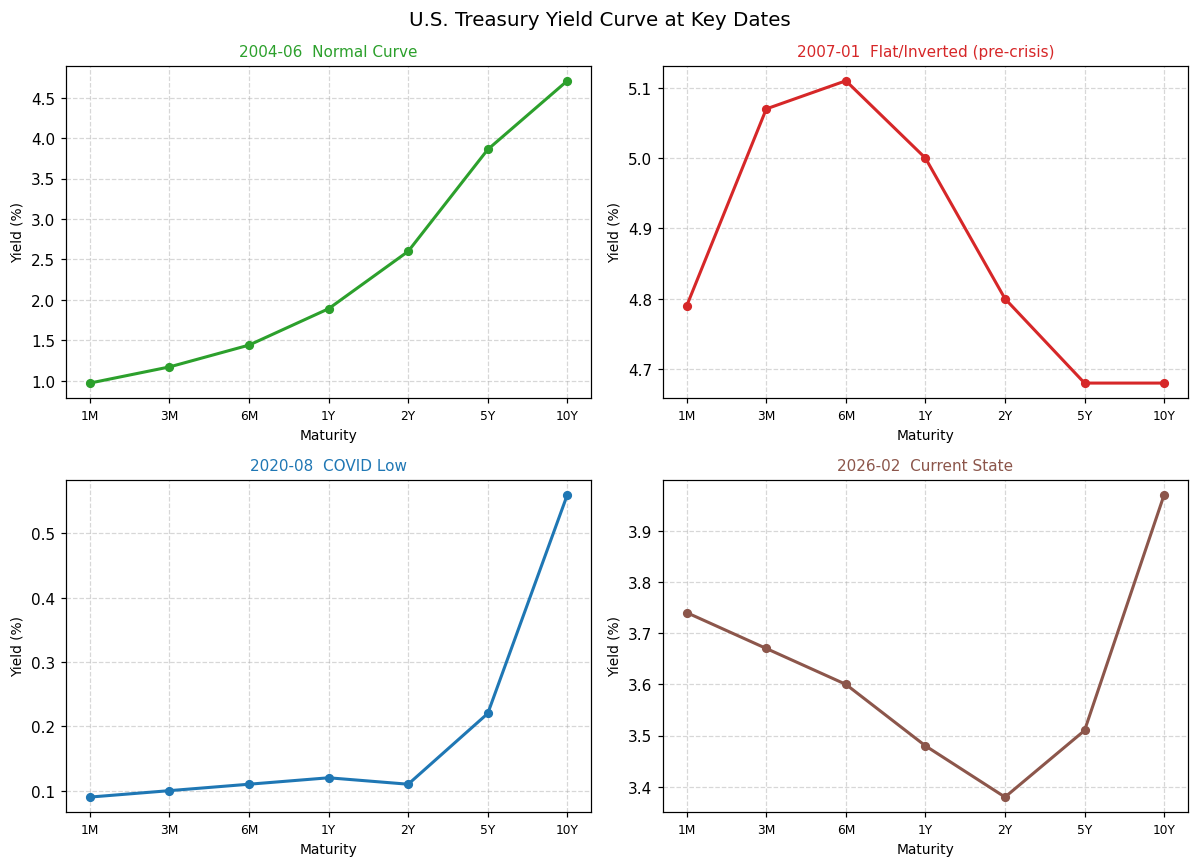

In [54]:
maturities_years = [1/12, 3/12, 6/12, 1, 2, 5, 10]
maturities_years = np.arange(7)

snapshot_dates = {
    '2004-06-01': ('Normal Curve', 'tab:green'),
    '2007-01-02': ('Flat/Inverted (pre-crisis)', 'tab:red'),
    '2020-08-03': ('COVID Low', 'tab:blue'),
    'latest':     ('Current State', 'tab:brown'),
}

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()

for ax, (date_str, (label, color)) in zip(axes, snapshot_dates.items()):
    if date_str == 'latest':
        idx = -1
        date_str_display = raw.index[-1].strftime('%Y-%m')
    else:
        date = pd.Timestamp(date_str)
        idx = raw.index.get_indexer([date], method='nearest')[0]
        date_str_display = date_str[:7]

    yields = raw.iloc[idx][CURVE_TICKERS].values
    ax.plot(maturities_years, yields, marker='o', color=color,
            linewidth=2, markersize=5)
    ax.set_xticks(maturities_years)
    ax.set_xticklabels(MATURITY_LABELS, fontsize=8)
    ax.set_xlabel('Maturity', fontsize=9)
    ax.set_ylabel('Yield (%)', fontsize=9)
    ax.set_title(f'{date_str_display}  {label}', fontsize=10, color=color)
    ax.grid(True, linestyle='--', alpha=0.5)

fig.suptitle('U.S. Treasury Yield Curve at Key Dates', fontsize=13)
plt.tight_layout()
plt.show()


## 2.2 Доходности DBAA и Treasury в динамике

Совместное движение доходности корпоративных облигаций (DBAA) и ключевых точек кривой Treasury.

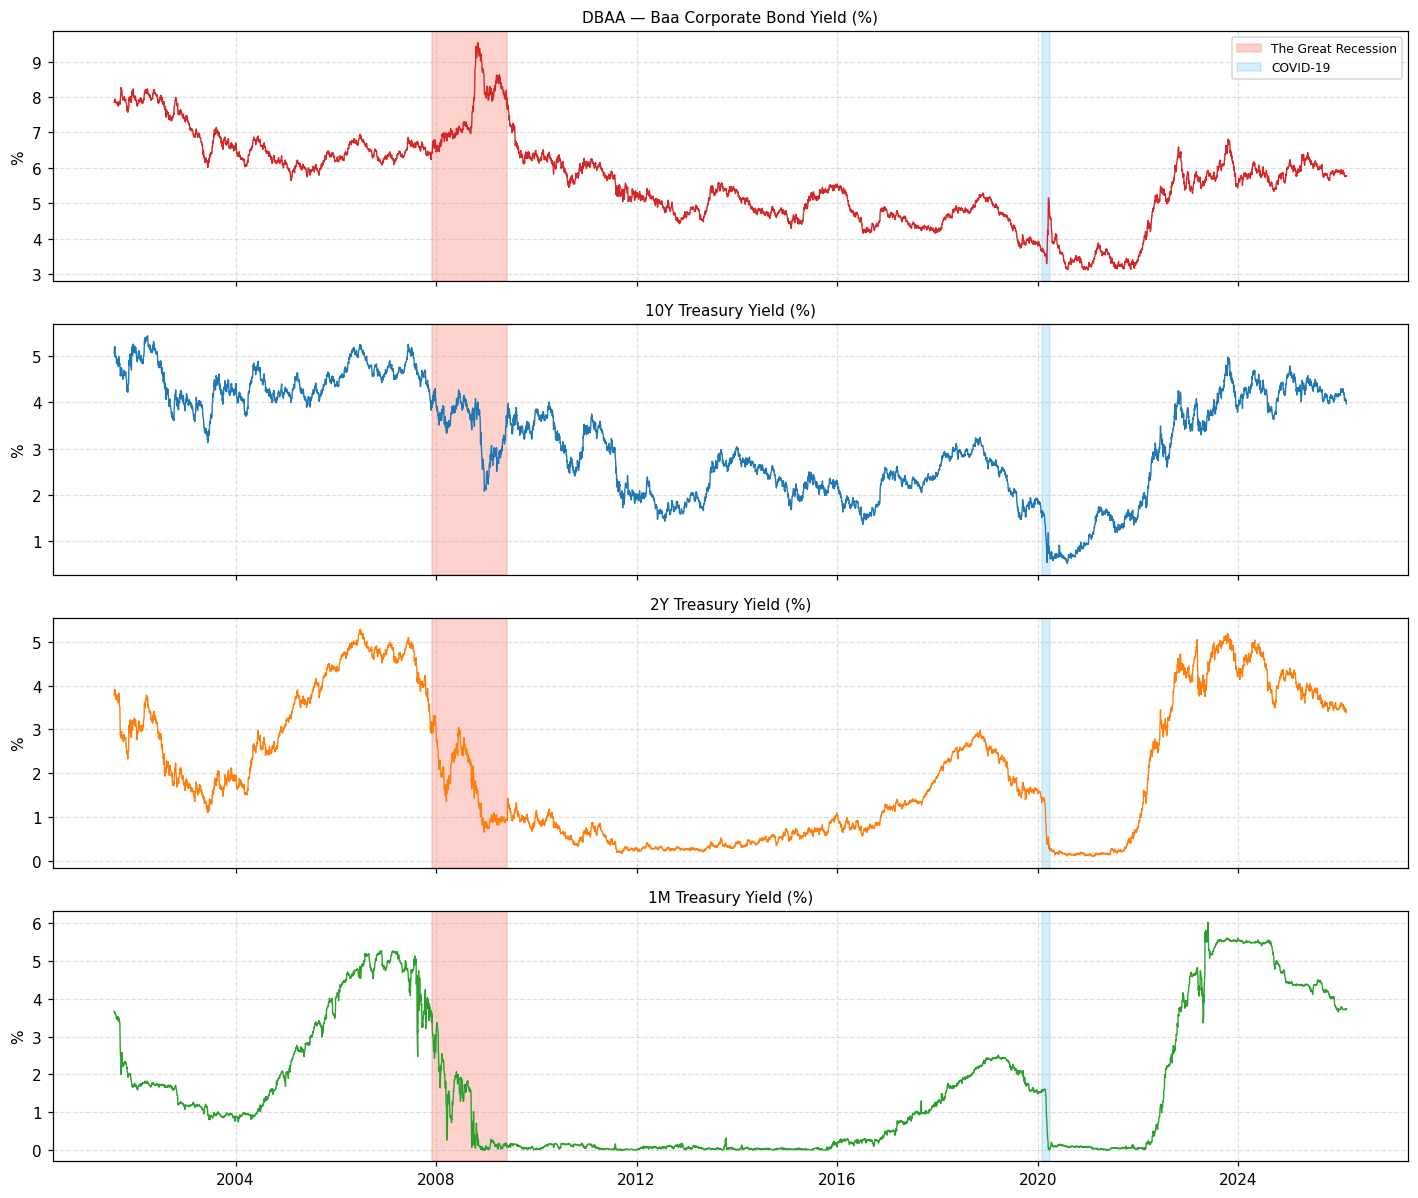

In [4]:
crises = [
    ('2007-12-01', '2009-06-01', 'salmon', 'The Great Recession'),
    ('2020-02-01', '2020-04-01', 'lightskyblue', 'COVID-19'),
]

fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)

plot_series = [
    (PRODUCT,    'DBAA — Baa Corporate Bond Yield (%)',  'tab:red'),
    ('DGS10',   '10Y Treasury Yield (%)',                'tab:blue'),
    ('DGS2',    '2Y Treasury Yield (%)',                 'tab:orange'),
    ('DGS1MO',  '1M Treasury Yield (%)',                 'tab:green'),
]

for ax, (col, title, color) in zip(axes, plot_series):
    ax.plot(raw.index, raw[col], color=color, linewidth=0.9)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('%')
    ax.grid(True, linestyle='--', alpha=0.4)
    for s, e, c, n in crises:
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), color=c, alpha=0.35,
                   label=n if ax is axes[0] else '_nolegend_')

axes[0].legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

## 2.3 Подготовка данных: ежедневные изменения

Добавляем небольшой случайный шум (U[-0.005, 0.005]) для устранения точечных масс в нуле — аналогично подходу из предыдущих ноутбуков. Затем вычисляем ежедневные изменения доходностей.

In [5]:
np.random.seed(42)
raw_noisy = raw.copy()
raw_noisy += np.random.uniform(-0.005, 0.005, size=raw.shape)
changes = raw_noisy.diff().dropna()

print(f"Observations after differencing: {len(changes)}")
print(f"Zero fraction per series:")
print((changes == 0).mean().round(4))

Observations after differencing: 6139
Zero fraction per series:
DBAA      0.0
DGS1MO    0.0
DGS3MO    0.0
DGS6MO    0.0
DGS1      0.0
DGS2      0.0
DGS5      0.0
DGS10     0.0
dtype: float64


# 3. PCA на кривой доходностей Treasury

Основная идея: ежедневные движения всей кривой доходностей (7 точек: 1M–10Y) можно описать тремя факторами, которые традиционно интерпретируются как:
- PC1 — Level (уровень): параллельный сдвиг всей кривой (все ставки движутся в одном направлении)
- PC2 — Slope (наклон): изменение наклона — краткосрочные против долгосрочных ставок
- PC3 — Curvature (кривизна): изменение выпуклости — средний участок против крайних точек кривой

In [6]:
curve_changes = changes[CURVE_TICKERS].values

pca = PCA(n_components=3)
pca.fit(curve_changes)

exp_var = pca.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

print("PCA — Explained Variance")
print(f"{'PC':<6} {'Explained':>12} {'Cumulative':>12}")
print("─" * 32)
for i, (ev, cv) in enumerate(zip(exp_var, cum_var)):
    print(f"PC{i+1:<4} {ev*100:>11.2f}% {cv*100:>11.2f}%")

pc_scores = pca.transform(curve_changes)
pc_df = pd.DataFrame(pc_scores, index=changes.index, columns=['PC1', 'PC2', 'PC3'])

PCA — Explained Variance
PC        Explained   Cumulative
────────────────────────────────
PC1          59.09%       59.09%
PC2          24.39%       83.48%
PC3           8.77%       92.25%


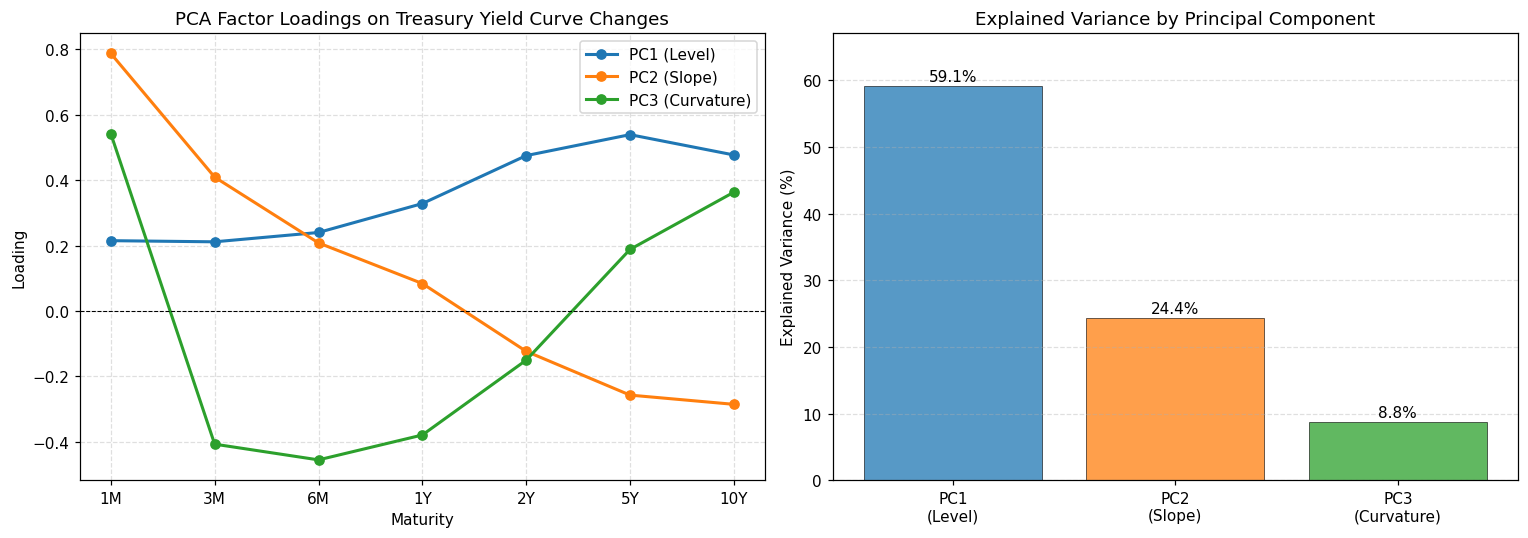

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Factor loadings
ax = axes[0]
colors_pc = ['tab:blue', 'tab:orange', 'tab:green']
for i, (pc_label, color) in enumerate(zip(['PC1 (Level)', 'PC2 (Slope)', 'PC3 (Curvature)'], colors_pc)):
    ax.plot(MATURITY_LABELS, pca.components_[i], marker='o', linewidth=2,
            markersize=6, color=color, label=pc_label)
ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
ax.set_xlabel('Maturity')
ax.set_ylabel('Loading')
ax.set_title('PCA Factor Loadings on Treasury Yield Curve Changes')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)

# Scree / explained variance
ax = axes[1]
bars = ax.bar(['PC1\n(Level)', 'PC2\n(Slope)', 'PC3\n(Curvature)'],
              exp_var * 100, color=colors_pc, alpha=0.75, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, exp_var * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Explained Variance (%)')
ax.set_title('Explained Variance by Principal Component')
ax.set_ylim(0, max(exp_var)*100 + 8)
ax.grid(True, linestyle='--', alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

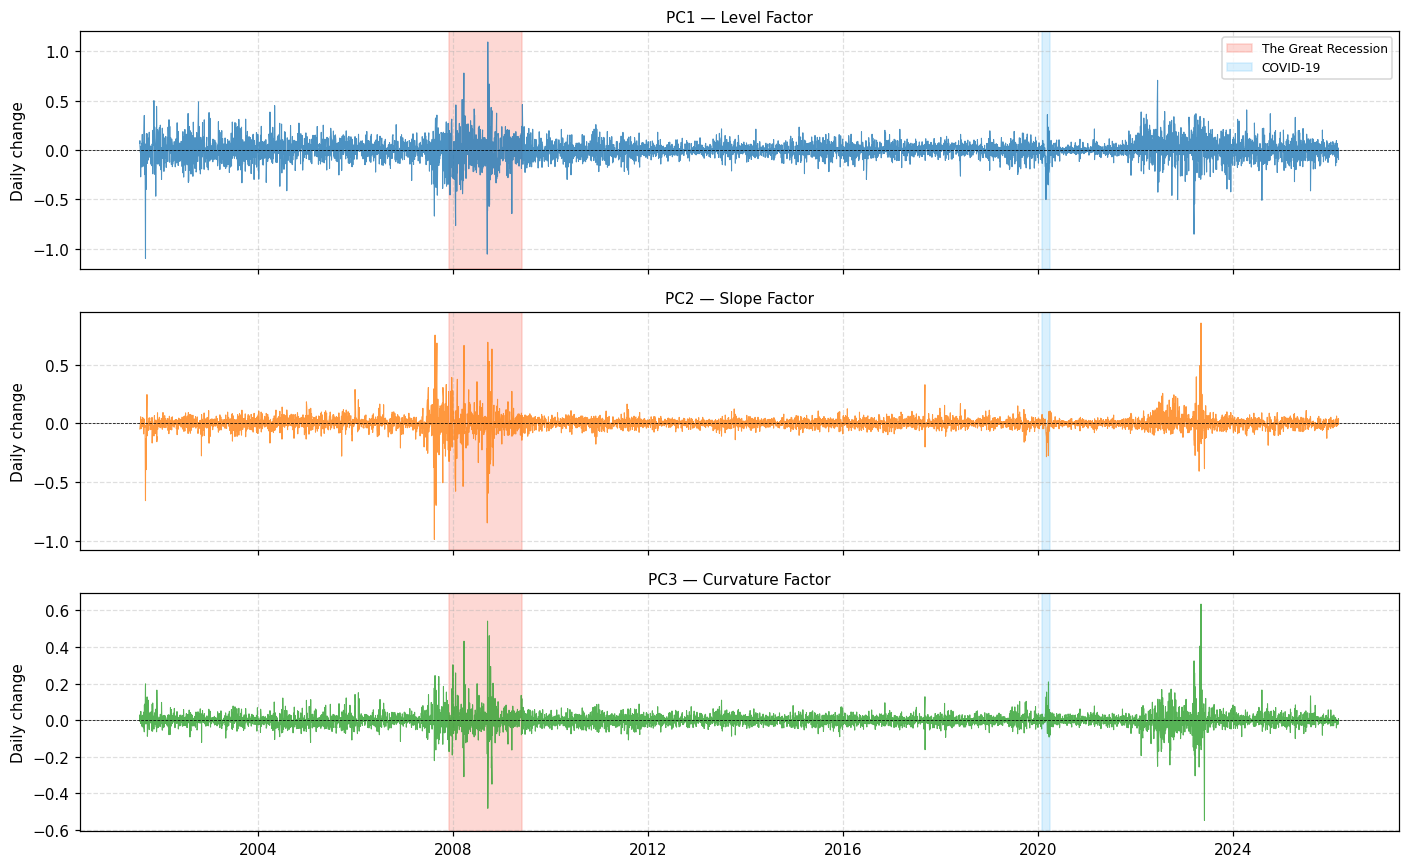

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

pc_info = [
    ('PC1', 'PC1 — Level Factor', 'tab:blue'),
    ('PC2', 'PC2 — Slope Factor', 'tab:orange'),
    ('PC3', 'PC3 — Curvature Factor', 'tab:green'),
]

for ax, (col, title, color) in zip(axes, pc_info):
    ax.plot(pc_df.index, pc_df[col], color=color, linewidth=0.7, alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('Daily change')
    ax.grid(True, linestyle='--', alpha=0.4)
    for s, e, c, n in crises:
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), color=c, alpha=0.30,
                   label=n if ax is axes[0] else '_nolegend_')

axes[0].legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

# 4. Маргинальные распределения

Для каждого из 4 рядов (DBAA и PC1–PC3) подбираем наилучшее маргинальное распределение.

## 4.1 Тест Льюнга-Бокса на ARCH-эффекты

Перед выбором GARCH проверим, присутствует ли автокорреляция квадратов (кластеризация волатильности) в каждом ряду.

In [9]:
from statsmodels.stats.diagnostic import acorr_ljungbox

all_series = {
    'DBAA': changes[PRODUCT].values,
    'PC1':  pc_df['PC1'].values,
    'PC2':  pc_df['PC2'].values,
    'PC3':  pc_df['PC3'].values,
}

print("=== Ljung-Box Test on Squared Series (H₀: No ARCH effects) ===")
for name, y in all_series.items():
    lb = acorr_ljungbox(y**2, lags=10, return_df=True)
    pval = lb['lb_pvalue'].iloc[-1]
    print(f"  {name:<6}: p-value = {pval:.4e}  → {'ARCH effects present' if pval < 0.05 else 'No ARCH'}")

=== Ljung-Box Test on Squared Series (H₀: No ARCH effects) ===
  DBAA  : p-value = 0.0000e+00  → ARCH effects present
  PC1   : p-value = 0.0000e+00  → ARCH effects present
  PC2   : p-value = 0.0000e+00  → ARCH effects present
  PC3   : p-value = 1.3376e-231  → ARCH effects present


## 4.2 Подбор распределений: GARCH(1,1) с тремя типами распределений

Сравниваем три варианта иноваций GARCH(1,1): нормальное, t-Стьюдента и Skew-t — по критерию BIC.

In [10]:
distributions = ['normal', 't', 'skewt']
dist_labels = {'normal': 'Normal', 't': "Student's t", 'skewt': 'Skew-t'}

garch_fits = {d: {} for d in distributions}

for dist in distributions:
    for name, y in all_series.items():
        m = arch_model(y, mean='Zero', vol='GARCH', p=1, q=1, dist=dist, rescale=False)
        res = m.fit(disp='off')
        garch_fits[dist][name] = res

bic_rows = []
for name in all_series:
    row = {'Series': name}
    best_bic = min(garch_fits[d][name].bic for d in distributions)
    for dist in distributions:
        bic = garch_fits[dist][name].bic
        row[dist_labels[dist]] = bic
        row[f'_best_{dist}'] = (bic == best_bic)
    bic_rows.append(row)

df_bic = pd.DataFrame(bic_rows).set_index('Series')
display_cols = [dist_labels[d] for d in distributions]

def highlight_min(row):
    vals = row[display_cols]
    return ['font-weight: bold;' if v == vals.min() else '' for v in vals]

print("BIC Comparison — lower is better (best per row in bold)")
df_bic[display_cols].style.apply(highlight_min, axis=1).format("{:.1f}")

BIC Comparison — lower is better (best per row in bold)


,Normal,Student's t,Skew-t
Series,,,
DBAA,-19523.0,-19601.2,-19592.5
PC1,-12418.7,-12780.5,-12771.8
PC2,-20706.7,-21408.9,-21401.4
PC3,-25290.5,-25729.0,-25720.3


## 4.3 Финальный выбор: GARCH(1,1)-t

Аналогично подходу из предыдущих ноутбуков, для всех рядов выбираем GARCH(1,1)-t как наилучший баланс между качеством подгонки и количеством параметров. BIC штрафует за лишний параметр асимметрии skew-t, что оправдывает более простую модель.

Сохраняем финальные подгонки и стандартизованные остатки.

In [11]:
garch_t = {}
std_resids = {}

for name, y in all_series.items():
    res = garch_fits['t'][name]
    garch_t[name] = res
    std_resids[name] = res.resid / res.conditional_volatility

summary_rows = []
for name in all_series:
    res = garch_t[name]
    p = res.params
    persist = p['alpha[1]'] + p['beta[1]']
    summary_rows.append({
        'Series':          name,
        'ω':               f"{p['omega']:.2e}",
        'α (shock)':       f"{p['alpha[1]']:.3f}",
        'β (persistence)': f"{p['beta[1]']:.3f}",
        'α+β':             f"{persist:.3f}",
        'ν (tail d.f.)':   f"{p['nu']:.2f}",
    })

pd.DataFrame(summary_rows).set_index('Series')

,ω,α (shock),β (persistence),α+β,ν (tail d.f.)
Series,,,,,
DBAA,5.69e-05,0.050,0.930,0.980,10.51
PC1,2.26e-04,0.100,0.880,0.980,5.52
PC2,5.93e-05,0.118,0.859,0.977,5.77
PC3,3.35e-05,0.100,0.880,0.980,5.68


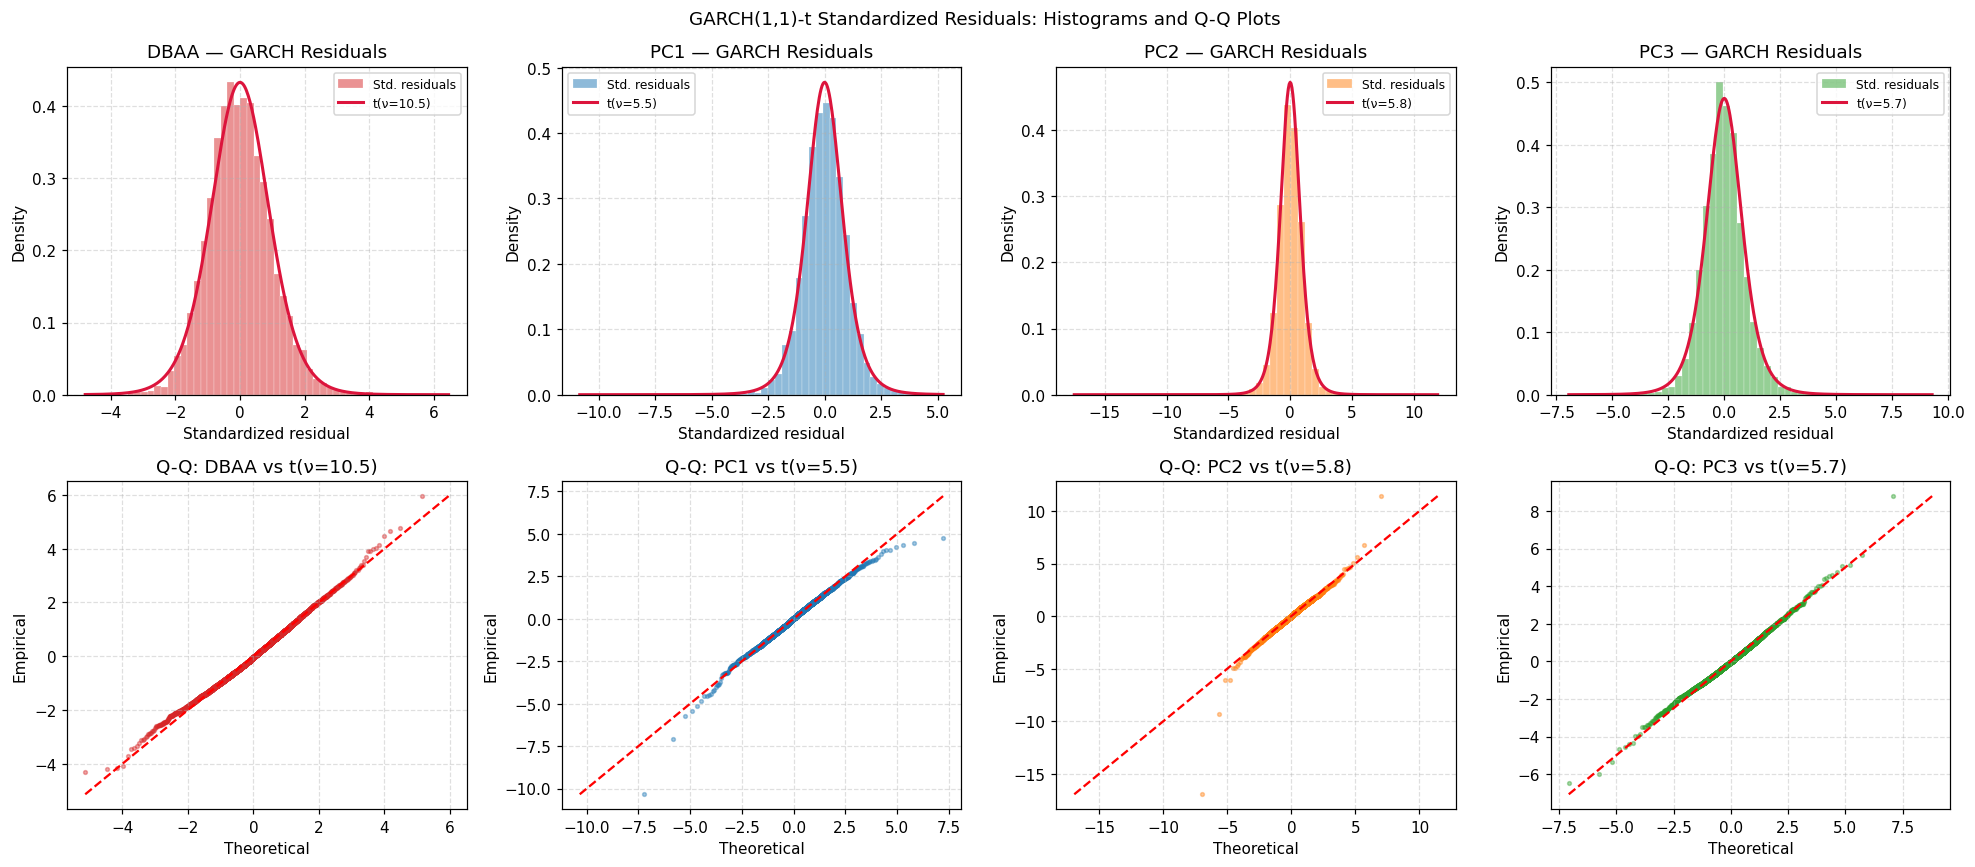

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
series_colors = {'DBAA': 'tab:red', 'PC1': 'tab:blue', 'PC2': 'tab:orange', 'PC3': 'tab:green'}

for j, name in enumerate(['DBAA', 'PC1', 'PC2', 'PC3']):
    resid = std_resids[name]
    nu = garch_t[name].params['nu']
    scale = np.sqrt((nu - 2) / nu)

    # Histogram
    ax = axes[0, j]
    ax.hist(resid, bins=50, density=True, color=series_colors[name], alpha=0.5,
            edgecolor='white', linewidth=0.3, label='Std. residuals')
    x = np.linspace(resid.min() - 0.5, resid.max() + 0.5, 400)
    ax.plot(x, stats.t.pdf(x, df=nu, loc=0, scale=scale), color='crimson',
            linewidth=2, label=f't(ν={nu:.1f})')
    ax.set_title(f'{name} — GARCH Residuals')
    ax.set_xlabel('Standardized residual')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

    # Q-Q plot
    ax = axes[1, j]
    empirical = np.sort(resid)
    n = len(empirical)
    probs = (np.arange(1, n + 1) - 0.5) / n
    theoretical = stats.t.ppf(probs, df=nu, loc=0, scale=scale)
    ax.scatter(theoretical, empirical, alpha=0.4, s=6, color=series_colors[name])
    lim = [min(theoretical.min(), empirical.min()), max(theoretical.max(), empirical.max())]
    ax.plot(lim, lim, color='red', linestyle='--', linewidth=1.5)
    ax.set_title(f'Q-Q: {name} vs t(ν={nu:.1f})')
    ax.set_xlabel('Theoretical')
    ax.set_ylabel('Empirical')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('GARCH(1,1)-t Standardized Residuals: Histograms and Q-Q Plots', fontsize=12)
plt.tight_layout()
plt.show()

# 5. PIT: трансформация в U[0,1]

Применяем Probability Integral Transform к стандартизованным остаткам каждой GARCH-t модели. Результат — псевдонаблюдения $u_{i,t} \in (0,1)$, равномерно распределённые при верной спецификации маргиналов.

Copula data matrix U: shape = (6139, 4)
NaN count: 0


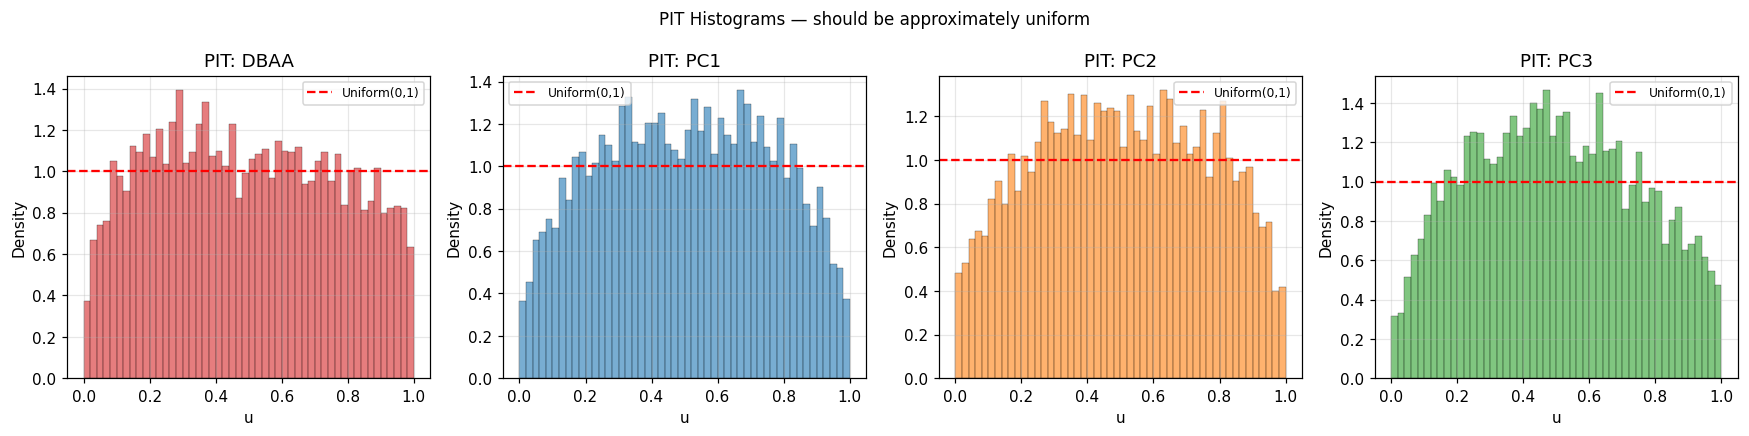

In [13]:
VARS = ['DBAA', 'PC1', 'PC2', 'PC3']

uniforms = {}
for name in VARS:
    nu = garch_t[name].params['nu']
    u = stats.t.cdf(std_resids[name], df=nu)
    uniforms[name] = np.clip(u, 1e-7, 1 - 1e-7)

U = np.column_stack([uniforms[v] for v in VARS])
T, d = U.shape
print(f"Copula data matrix U: shape = {U.shape}")
print(f"NaN count: {np.isnan(U).sum()}")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors_vars = ['tab:red', 'tab:blue', 'tab:orange', 'tab:green']
for ax, name, color in zip(axes, VARS, colors_vars):
    ax.hist(uniforms[name], bins=50, range=(0, 1), density=True,
            color=color, alpha=0.6, edgecolor='black', linewidth=0.3)
    ax.axhline(1, color='red', linestyle='--', linewidth=1.5, label='Uniform(0,1)')
    ax.set_title(f'PIT: {name}')
    ax.set_xlabel('u')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle('PIT Histograms — should be approximately uniform', fontsize=11)
plt.tight_layout()
plt.show()

# 6. Динамическая многомерная t-копула (DCC)

## 6.1 Модель DCC(1,1)

Для описания совместного распределения (DBAA, PC1, PC2, PC3) используется Dynamic Conditional Correlation t-копула (DCC, Engle 2002):

Шаг 1. Из PIT-преобразования получаем псевдонаблюдения $u_{i,t} \in (0,1)$.

Шаг 2. Трансформируем в переменные копулы: $z_{i,t} = t_\nu^{-1}(u_{i,t})$, где $\nu$ — степени свободы копулы (оценивается совместно с параметрами DCC).

Шаг 3. Динамика матрицы корреляций задаётся процессом DCC(1,1):
$$Q_t = (1 - a - b)\,\bar{Q} + a\,z_{t-1}z_{t-1}^\top + b\,Q_{t-1}$$
$$R_t = \mathrm{diag}(Q_t)^{-1/2}\,Q_t\,\mathrm{diag}(Q_t)^{-1/2}$$

где $\bar{Q}$ — безусловная матрица корреляций $z$-баллов, а параметры $a, b > 0$, $a + b < 1$.

Шаг 4. Логарифмическое правдоподобие копулы в момент $t$:
$$\log c_t = \log f_t^{(d)}(z_t;\, R_t, \nu) - \sum_{i=1}^d \log f_t^{(1)}(z_{it};\, \nu)$$

где $f_t^{(d)}$ — плотность многомерного $t$-распределения, $f_t^{(1)}$ — одномерного.

Оцениваемые параметры: $\theta = (a,\, b,\, \nu)$.

In [14]:
def dcc_filter(Z, a, b, Q_bar):
    """DCC(1,1) correlation filter. Returns R_t sequence: (T, d, d)."""
    T, d = Z.shape
    Q = Q_bar.copy()
    R_seq = np.empty((T, d, d))
    for t in range(T):
        if t > 0:
            Q = (1 - a - b) * Q_bar + a * np.outer(Z[t-1], Z[t-1]) + b * Q
        dq = np.sqrt(np.diag(Q))
        R = Q / np.outer(dq, dq)
        np.fill_diagonal(R, 1.0)
        R_seq[t] = R
    return R_seq


def dcc_t_nll(params, U, d):
    """Negative log-likelihood of DCC(1,1) multivariate t-copula."""
    a_raw, b_raw, log_nu = params

    # sigmoid reparametrization ensures a,b in (0,1)
    a = 1.0 / (1.0 + np.exp(-a_raw))
    b = 1.0 / (1.0 + np.exp(-b_raw))
    if a + b >= 0.999:
        return 1e12
    nu = np.exp(log_nu)

    Z = stats.t.ppf(U, df=nu)
    if not np.all(np.isfinite(Z)):
        return 1e12

    Q_bar = np.corrcoef(Z.T)
    R_seq = dcc_filter(Z, a, b, Q_bar)

    # Constant log-likelihood terms
    lc_mv = (special.gammaln((nu + d) / 2) - special.gammaln(nu / 2)
             - (d / 2) * np.log(np.pi * nu))
    lc_1  = (special.gammaln((nu + 1) / 2) - special.gammaln(nu / 2)
             - 0.5 * np.log(np.pi * nu))

    nll = 0.0
    for t in range(len(Z)):
        R = R_seq[t]
        z = Z[t]
        sign, logdet = np.linalg.slogdet(R)
        if sign <= 0:
            return 1e12
        R_inv = np.linalg.inv(R)
        quad = z @ R_inv @ z
        log_c = (lc_mv - 0.5 * logdet
                 - (nu + d) / 2.0 * np.log(1.0 + quad / nu)
                 - d * lc_1 + (nu + 1) / 2.0 * np.sum(np.log(1.0 + z**2 / nu)))
        nll -= log_c
    return nll


print("DCC t-copula functions defined.")

DCC t-copula functions defined.


## 6.2 Оптимизация параметров DCC

In [17]:
starting_points = [
    [-2.0, -2.0, np.log(6)],
    [-1.5, -2.5, np.log(8)],
    [-2.5, -1.5, np.log(5)],
    [-1.0, -3.0, np.log(10)],
    [-3.0, -1.0, np.log(4)],
]

best_result = None
for i, x0 in enumerate(starting_points):
    res = minimize(
        dcc_t_nll, x0, args=(U, d),
        method='L-BFGS-B',
        options={'maxiter': 500, 'ftol': 1e-10, 'gtol': 1e-7}
    )
    if best_result is None or res.fun < best_result.fun:
        best_result = res
    print(f"  Start {i+1}: nll={res.fun:.2f}  converged={res.success}")

a_raw_hat, b_raw_hat, log_nu_hat = best_result.x
a_hat  = 1.0 / (1.0 + np.exp(-a_raw_hat))
b_hat  = 1.0 / (1.0 + np.exp(-b_raw_hat))
nu_hat = np.exp(log_nu_hat)
ll_hat = -best_result.fun

print("\n" + "=" * 50)
print("  DCC(1,1) t-Copula — Estimated Parameters")
print("=" * 50)
print(f"  a  (shock to correlation)   = {a_hat:.6f}")
print(f"  b  (persistence)            = {b_hat:.6f}")
print(f"  a + b                       = {a_hat + b_hat:.6f}")
print(f"  ν  (tail d.o.f.)            = {nu_hat:.4f}")
print(f"  Log-likelihood              = {ll_hat:.4f}")
print(f"  Converged                   : {best_result.success}")

  Start 1: nll=-6836.69  converged=True
  Start 2: nll=-6883.27  converged=True
  Start 3: nll=-7040.33  converged=True
  Start 4: nll=-7105.58  converged=True
  Start 5: nll=-6954.12  converged=True

  DCC(1,1) t-Copula — Estimated Parameters
  a  (shock to correlation)   = 0.044623
  b  (persistence)            = 0.954344
  a + b                       = 0.998967
  ν  (tail d.o.f.)            = 3.8799
  Log-likelihood              = 7105.5784
  Converged                   : True


In [ ]:
import json

dcc_results = {
    'raw_x':  best_result.x.tolist(),
    'a_hat':  a_hat,
    'b_hat':  b_hat,
    'nu_hat': nu_hat,
    'll_hat': ll_hat,
}
with open('dcc_params.json', 'w') as f:
    json.dump(dcc_results, f, indent=2)
print("Saved → dcc_params.json")

Saved → dcc_params.json


In [15]:
import json

with open('dcc_params.json') as f:
    _p = json.load(f)

a_hat  = _p['a_hat']
b_hat  = _p['b_hat']
nu_hat = _p['nu_hat']
ll_hat = _p['ll_hat']

print(f"Loaded DCC params:")
print(f"  a      = {a_hat:.6f}")
print(f"  b      = {b_hat:.6f}")
print(f"  a + b  = {a_hat + b_hat:.6f}")
print(f"  ν      = {nu_hat:.4f}")
print(f"  LL     = {ll_hat:.4f}")

Loaded DCC params:
  a      = 0.044623
  b      = 0.954344
  a + b  = 0.998967
  ν      = 3.8799
  LL     = 7105.5784


## 6.3 Динамические корреляции DBAA с PCA факторами кривой

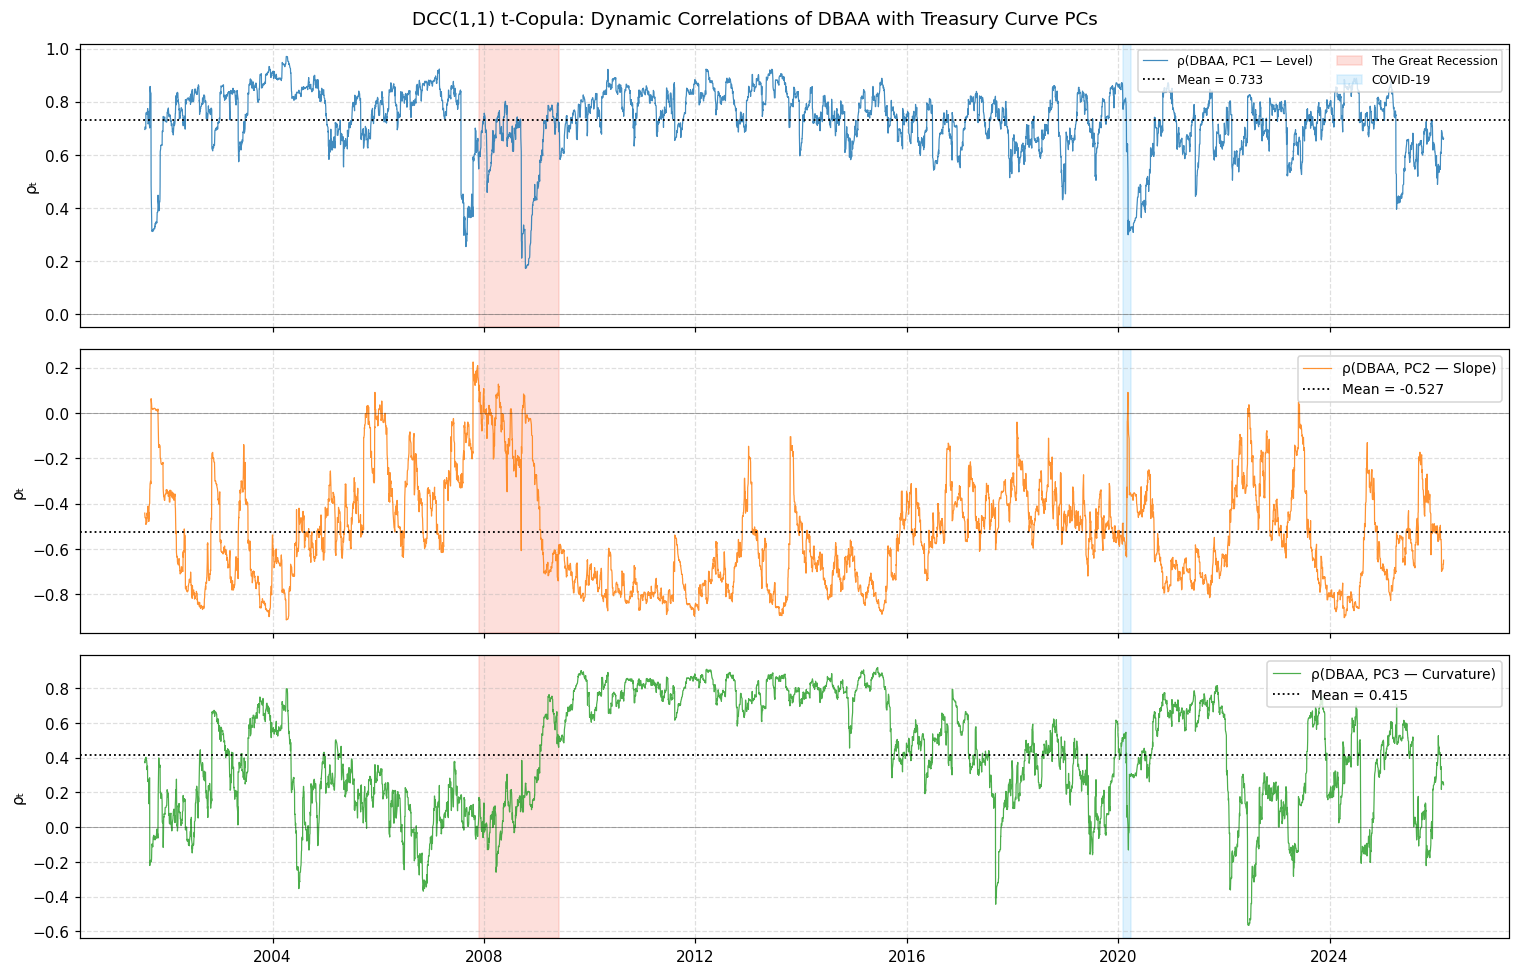


Unconditional correlation matrix (R̄):
       DBAA    PC1    PC2    PC3
DBAA  1.000  0.695 -0.442  0.377
PC1   0.695  1.000 -0.280  0.199
PC2  -0.442 -0.280  1.000 -0.162
PC3   0.377  0.199 -0.162  1.000


In [16]:
# Compute final DCC path at estimated parameters
Z_hat   = stats.t.ppf(U, df=nu_hat)
Q_bar_hat = np.corrcoef(Z_hat.T)
R_seq   = dcc_filter(Z_hat, a_hat, b_hat, Q_bar_hat)

dates = changes.index

# Extract correlations of DBAA (index 0) with PC1, PC2, PC3
rho_dbaa_pc1 = R_seq[:, 0, 1]
rho_dbaa_pc2 = R_seq[:, 0, 2]
rho_dbaa_pc3 = R_seq[:, 0, 3]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

corr_pairs = [
    (rho_dbaa_pc1, 'ρ(DBAA, PC1 — Level)',    'tab:blue'),
    (rho_dbaa_pc2, 'ρ(DBAA, PC2 — Slope)',    'tab:orange'),
    (rho_dbaa_pc3, 'ρ(DBAA, PC3 — Curvature)', 'tab:green'),
]

for ax, (rho, label, color) in zip(axes, corr_pairs):
    ax.plot(dates, rho, color=color, linewidth=0.8, alpha=0.85, label=label)
    ax.axhline(rho.mean(), color='black', linestyle=':', linewidth=1.2,
               label=f'Mean = {rho.mean():.3f}')
    ax.axhline(0, color='black', linewidth=0.5, alpha=0.4)
    ax.set_ylabel('ρₜ')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)
    for s, e, c, n in crises:
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), color=c, alpha=0.25,
                   label=n if ax is axes[0] else '_nolegend_')

axes[0].legend(loc='upper right', fontsize=8, ncol=2)
plt.suptitle('DCC(1,1) t-Copula: Dynamic Correlations of DBAA with Treasury Curve PCs',
             fontsize=12)
plt.tight_layout()
plt.show()

print("\nUnconditional correlation matrix (R̄):")
print(pd.DataFrame(Q_bar_hat, index=VARS, columns=VARS).round(3))

# 7. Условное распределение DBAA при заданном сценарии кривой

## 7.1 Аналитическая формула условного t-распределения

Ключевое свойство многомерного $t$-распределения: условное распределение также является $t$.

Пусть $z = (z_1, z_{-1})$, где $z_1$ — целевая переменная (DBAA), $z_{-1}$ — обусловливающие переменные (PC1, PC2, PC3). Тогда:

$$z_1 \,|\, z_{-1} = z^* \;\sim\; t\!\left(\nu + k,\;\; \mu^*,\;\; \sigma^{*2}\right)$$

где $k = 3$ (число обусловливающих переменных), и:
$$\mu^* = R_{1,-1}\,R_{-1,-1}^{-1}\,z^*, \qquad \sigma^{*2} = \frac{\nu + z^{*\top}R_{-1,-1}^{-1}z^*}{\nu + k}\,\bigl(R_{11} - R_{1,-1}\,R_{-1,-1}^{-1}\,R_{-1,1}\bigr)$$

In [33]:
def conditional_t_params(z_cond, R, nu, target_idx=0):
    """
    Parameters of z_target | z_cond under multivariate t(nu, 0, R).
    Returns (df_cond, mu_cond, scale_cond).
    """
    d_total = R.shape[0]
    cond_idx = [i for i in range(d_total) if i != target_idx]
    k = len(cond_idx)

    R11 = R[target_idx, target_idx]
    R12 = R[target_idx][cond_idx]             # (k,)
    R22 = R[np.ix_(cond_idx, cond_idx)]       # (k, k)
    R22_inv = np.linalg.inv(R22)

    mu    = R12 @ R22_inv @ z_cond
    quad  = z_cond @ R22_inv @ z_cond
    sigma2 = (nu + quad) / (nu + k) * (R11 - R12 @ R22_inv @ R12)
    sigma2 = max(sigma2, 1e-10)               # numerical safety

    return nu + k, mu, np.sqrt(sigma2)


def scenario_to_dbaa_cdf(
    curve_scenario_bps,   # dict {ticker: change in bps, e.g. 'DGS10': 50}
    pca_model,
    garch_models,         # dict {name: arch result}
    R_t,                  # (4,4) correlation matrix at time t*
    nu_cop,               # copula d.o.f.
    t_star_idx=-1,        # index into conditional_volatility arrays
):
    """
    Given a yield curve scenario (changes in bps for each Treasury maturity),
    return (delta_dbaa_grid [%], conditional_cdf) for plotting.
    """
    # Step 1: project yield changes onto PCA factors
    scenario_vec = np.array([curve_scenario_bps.get(tk, 0.0) / 100.0
                              for tk in CURVE_TICKERS])
    pc_changes = pca_model.transform(scenario_vec.reshape(1, -1))[0]  # (3,)

    # Step 2: standardize each PC change by its current GARCH volatility → PIT → copula z
    z_conds = []
    for i, pc_name in enumerate(['PC1', 'PC2', 'PC3']):
        res = garch_models[pc_name]
        sigma_t = float(res.conditional_volatility[t_star_idx])
        nu_m    = float(res.params['nu'])
        eps     = pc_changes[i] / sigma_t
        u_i     = np.clip(stats.t.cdf(eps, df=nu_m), 1e-7, 1 - 1e-7)
        z_i     = stats.t.ppf(u_i, df=nu_cop)
        z_conds.append(z_i)

    z_cond = np.array(z_conds)

    # Step 3: analytical conditional distribution of z_DBAA | z_PC
    # Variables: DBAA=0, PC1=1, PC2=2, PC3=3
    df_c, mu_c, scale_c = conditional_t_params(z_cond, R_t, nu_cop, target_idx=0)

    # Step 4: transform grid back to original DBAA change space
    sigma_dbaa = float(garch_models['DBAA'].conditional_volatility[t_star_idx])
    nu_dbaa    = float(garch_models['DBAA'].params['nu'])

    z_grid     = np.linspace(-20, 20, 5000)
    cdf_z      = stats.t.cdf((z_grid - mu_c) / scale_c, df=df_c)

    # z_DBAA (copula score) → u_DBAA → eps_DBAA (GARCH residual) → Δ(DBAA) [%]
    u_grid          = np.clip(stats.t.cdf(z_grid, df=nu_cop), 1e-7, 1 - 1e-7)
    eps_grid        = stats.t.ppf(u_grid, df=nu_dbaa)
    delta_dbaa_grid = sigma_dbaa * eps_grid * 100  # in basis points

    return delta_dbaa_grid, cdf_z


print("Conditional distribution functions defined.")

Conditional distribution functions defined.


## 7.2 Сценарии изменения кривой доходностей

Определяем типовые сценарии движения кривой Treasury (в базисных пунктах):

| Сценарий | 1M | 3M | 6M | 1Y | 2Y | 5Y | 10Y | Экономический смысл |
|---|---|---|---|---|---|---|---|---|
| Без изменений | 0 | 0 | 0 | 0 | 0 | 0 | 0 | Базовый |
| Параллельный сдвиг вверх | +5 | +5 | +5 | +5 | +5 | +5 | +5 | Ожидания роста ставки ЦБ |
| Параллельный сдвиг вниз | −5 | −5 | −5 | −5 | −5 | −5 | −5 | Смягчение денежно-крединтой политики |
| Увеличение наклона | 0 | 0 | 0 | +1 | +2 | +4 | +6 | Рост инфляционных ожиданий |
| Увеличение кривизны | +3 | −2 | −3 | −2 | −1 | +1 | +2 | Рост повышения ставок в короткой и длинной перспективе, но не в средней |
| Шок ставки ЦБ | +10 | +7 | +5 | +2 | +1 | 0 | 0 | Внезапное повышение ставки ФРС |

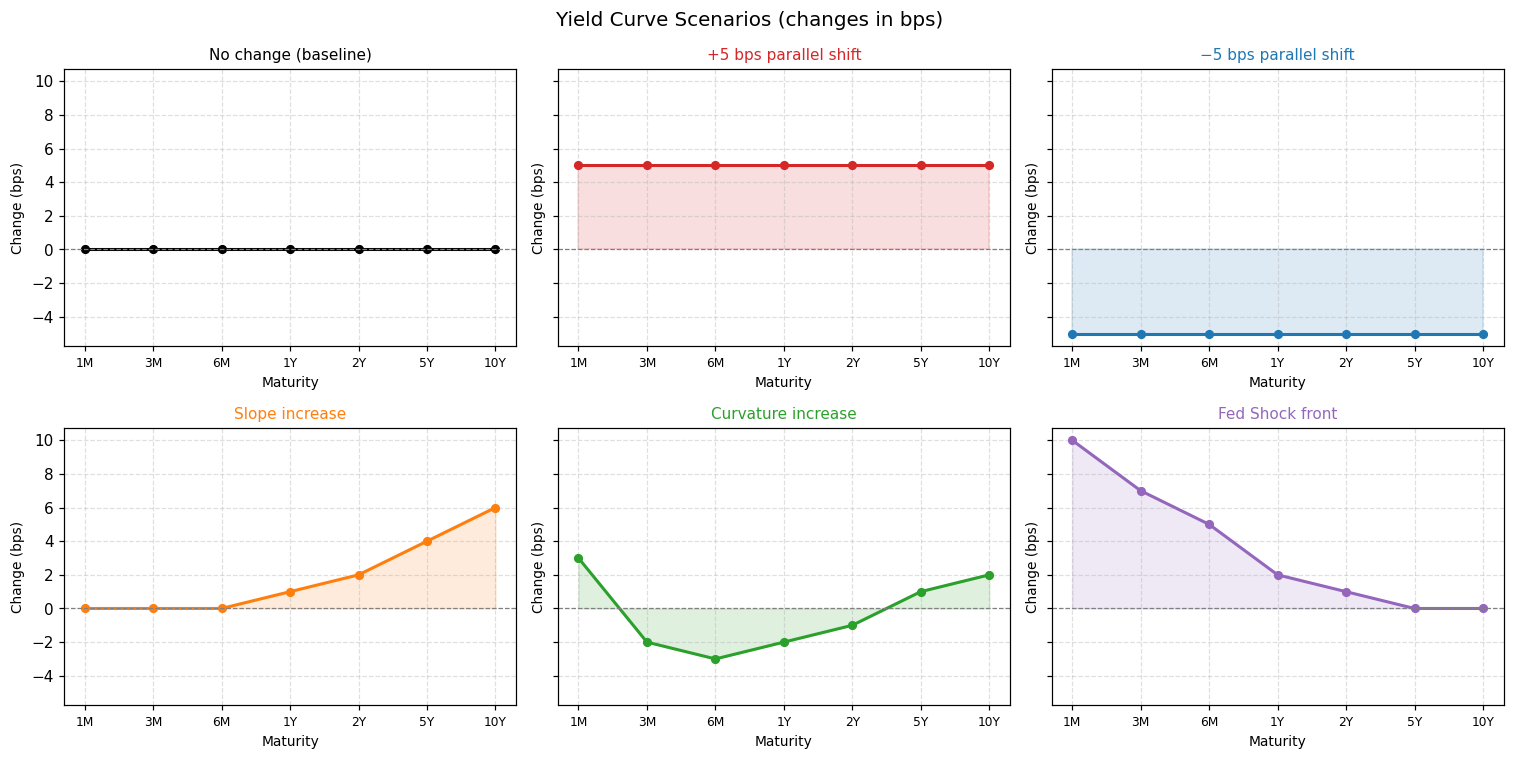

In [45]:
scenarios = {
    'No change (baseline)':       {tk: 0  for tk in CURVE_TICKERS},
    '+5 bps parallel shift':      {tk: +5 for tk in CURVE_TICKERS},
    '−5 bps parallel shift':      {tk: -5 for tk in CURVE_TICKERS},
    'Slope increase':  dict(zip(CURVE_TICKERS, [0, 0, 0,  1,  2,  4,  6])),
    'Curvature increase':  dict(zip(CURVE_TICKERS, [3, -2, -3, -2, -1, 1, 2])),
    'Fed Shock front': dict(zip(CURVE_TICKERS, [10, 7, 5, 2,  1,  0,  0])),
}


scenario_colors = ['black', 'tab:red', 'tab:blue', 'tab:orange', 'tab:green', 'tab:purple']

# Use the last available DCC correlation matrix and GARCH volatilities
R_current = R_seq[-1]

# Visualize scenarios on the curve
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
axes = axes.flatten()

for ax, (name, scenario), color in zip(axes, scenarios.items(), scenario_colors):
    chg = [scenario.get(tk, 0) for tk in CURVE_TICKERS]
    ax.plot(MATURITY_LABELS, chg, marker='o', markersize=5, linewidth=2, color=color)
    ax.fill_between(range(len(MATURITY_LABELS)), chg, alpha=0.15, color=color)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(name, fontsize=10, color=color)
    ax.set_xlabel('Maturity', fontsize=9)
    ax.set_ylabel('Change (bps)', fontsize=9)
    ax.set_xticks(range(len(MATURITY_LABELS)))
    ax.set_xticklabels(MATURITY_LABELS, fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

fig.suptitle('Yield Curve Scenarios (changes in bps)', fontsize=13)
plt.tight_layout()
plt.show()


## 7.3 Условные распределения DBAA по сценариям

Для каждого сценария строим условное распределение однодневного изменения DBAA-доходности (в б.п.) и сравниваем с безусловным распределением.

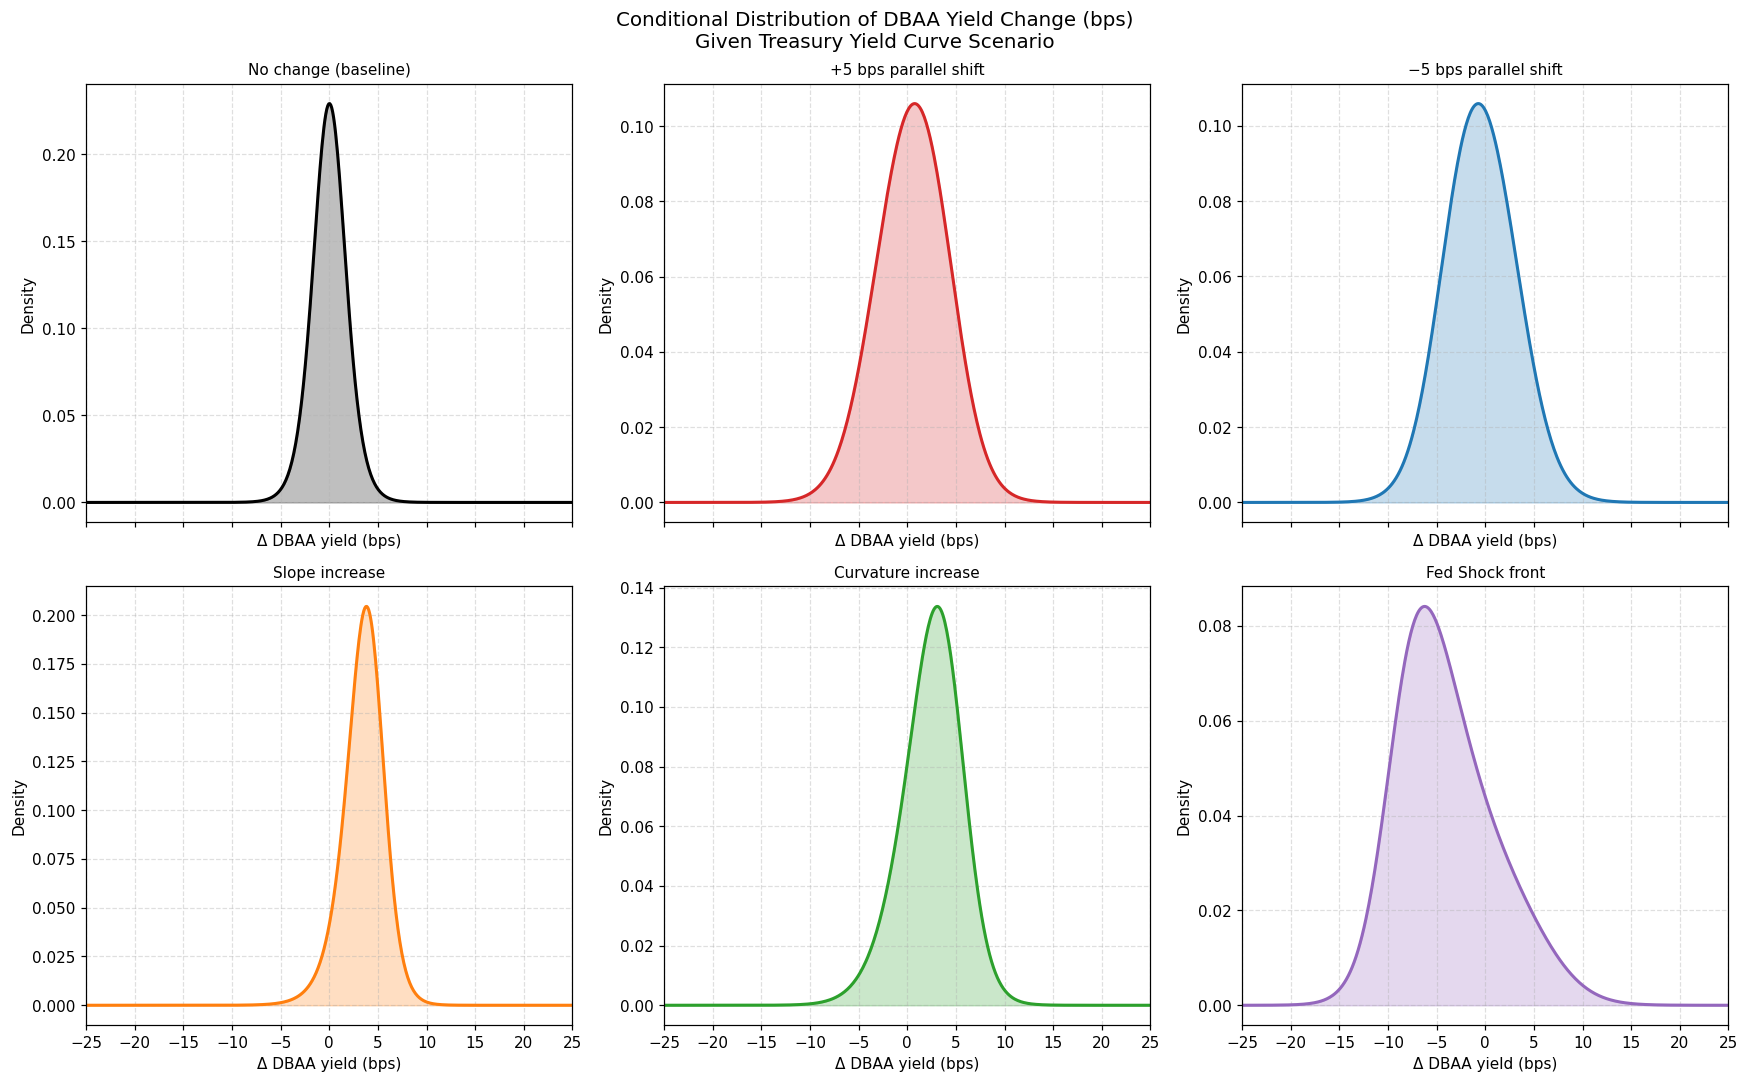

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True, sharey=False)
axes = axes.flatten()

quantile_levels = [0.05, 0.25, 0.50, 0.75, 0.95]
X_MIN, X_MAX = -25, 25
XTICKS = np.arange(X_MIN, X_MAX + 1, 5)

summary_rows = []

for ax, (name, scenario), color in zip(axes, scenarios.items(), scenario_colors):
    grid, cdf = scenario_to_dbaa_cdf(
        scenario, pca, garch_t, R_current, nu_hat, t_star_idx=-1
    )

    delta_uniform = np.linspace(X_MIN, X_MAX, 500)
    cdf_uniform = np.interp(delta_uniform, grid, cdf)
    pdf = np.gradient(cdf_uniform, delta_uniform)
    pdf = np.clip(pdf, 0, None)

    ax.fill_between(delta_uniform, pdf, color=color, alpha=0.25)
    ax.plot(delta_uniform, pdf, color=color, linewidth=2)

    ax.set_title(name.replace('\n', ' '), fontsize=10)
    ax.set_xlabel('Δ DBAA yield (bps)')
    ax.set_ylabel('Density')
    ax.set_xlim(X_MIN, X_MAX)
    ax.set_xticks(XTICKS)
    ax.grid(True, linestyle='--', alpha=0.4)

    quant_vals = np.interp(quantile_levels, cdf, grid)
    row = {'Scenario': name.replace('\n', ' ')}
    for q, qv in zip(quantile_levels, quant_vals):
        row[f'q{int(q*100)}'] = round(qv, 2)
    summary_rows.append(row)

plt.suptitle('Conditional Distribution of DBAA Yield Change (bps)\nGiven Treasury Yield Curve Scenario',
             fontsize=13)
plt.tight_layout()
plt.show()


## 7.4 Сводная таблица условных квантилей

Таблица показывает, как меняется распределение изменения DBAA-доходности в зависимости от сценария кривой.

In [47]:
df_summary = pd.DataFrame(summary_rows).set_index('Scenario')
df_summary.columns = ['5th pct', '25th pct', 'Median', '75th pct', '95th pct']
df_summary.index.name = 'Scenario'

print("Conditional quantiles of ΔDBAA (bps) by yield curve scenario")
print("=" * 80)
display(df_summary.style.format("{:.2f}").background_gradient(
    cmap='RdYlGn_r', axis=None, subset=df_summary.columns))

Conditional quantiles of ΔDBAA (bps) by yield curve scenario


,5th pct,25th pct,Median,75th pct,95th pct
Scenario,,,,,
No change (baseline),-3.07,-1.17,0.01,1.20,3.10
+5 bps parallel shift,-5.72,-1.98,0.58,3.08,6.57
−5 bps parallel shift,-6.55,-3.06,-0.55,2.01,5.74
Slope increase,-0.29,2.21,3.62,4.90,6.79
Curvature increase,-3.07,0.53,2.68,4.63,7.35
Fed Shock front,-11.39,-7.71,-4.67,-0.78,5.67


## 7.5 График условных распределений

Наложение всех сценариев позволяет сравнить сдвиги в медиане и «ширину» неопределённости.

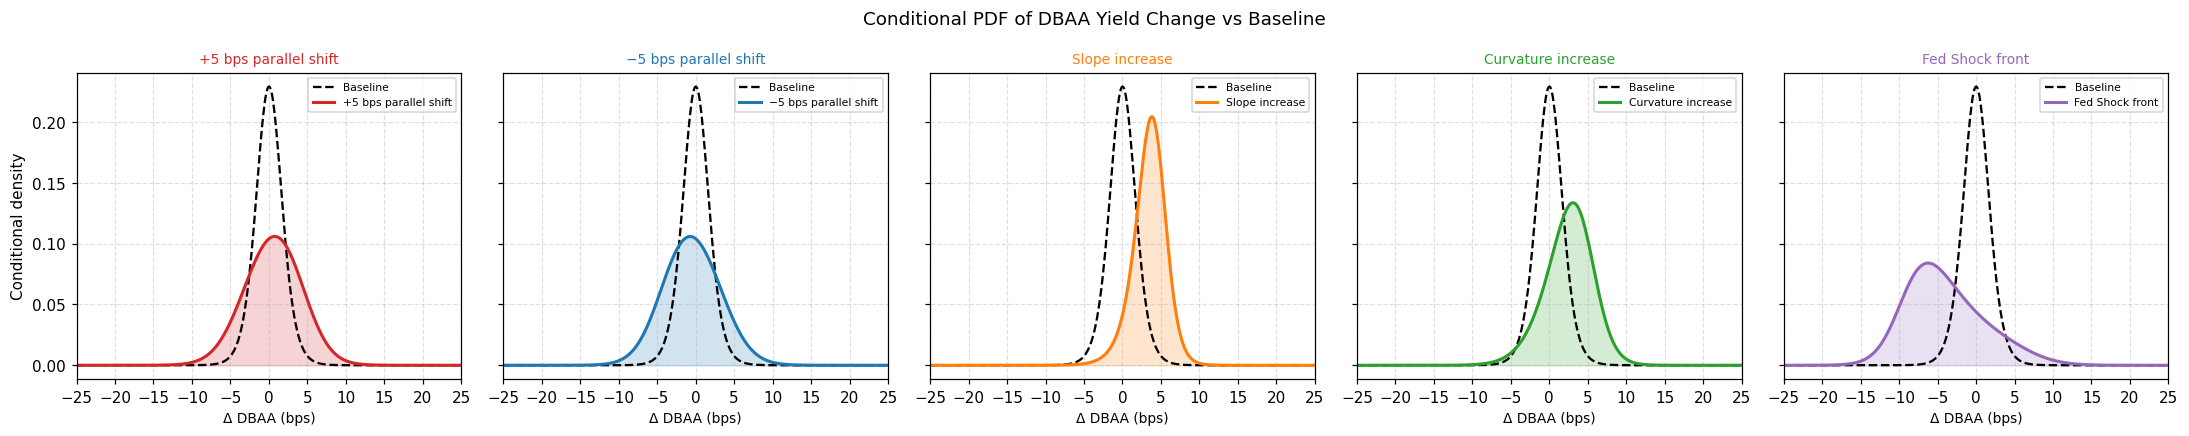

In [49]:
non_baseline = [(name, scenario, color) 
                for (name, scenario), color in zip(scenarios.items(), scenario_colors)
                if name != 'No change (baseline)']

baseline_scenario = scenarios['No change (baseline)']
baseline_grid, baseline_cdf = scenario_to_dbaa_cdf(baseline_scenario, pca, garch_t, R_current, nu_hat)
delta_uniform = np.linspace(-25, 25, 500)
baseline_pdf = np.clip(np.gradient(np.interp(delta_uniform, baseline_grid, baseline_cdf), delta_uniform), 0, None)

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

for ax, (name, scenario, color) in zip(axes, non_baseline):
    grid, cdf = scenario_to_dbaa_cdf(scenario, pca, garch_t, R_current, nu_hat)
    cdf_u = np.interp(delta_uniform, grid, cdf)
    pdf = np.clip(np.gradient(cdf_u, delta_uniform), 0, None)

    ax.plot(delta_uniform, baseline_pdf, color='black', linewidth=1.5, linestyle='--', label='Baseline')
    ax.fill_between(delta_uniform, pdf, color=color, alpha=0.2)
    ax.plot(delta_uniform, pdf, color=color, linewidth=2, label=name)

    ax.set_title(name, fontsize=9, color=color)
    ax.set_xlabel('Δ DBAA (bps)', fontsize=9)
    ax.set_xlim(-25, 25)
    ax.set_xticks(np.arange(-25, 26, 5))
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(fontsize=7)

axes[0].set_ylabel('Conditional density', fontsize=10)
fig.suptitle('Conditional PDF of DBAA Yield Change vs Baseline', fontsize=12)
plt.tight_layout()
plt.show()


Хотя число степеней свободы условного распределения $\nu_c + k$ больше безусловного $\nu_c$, что само по себе означает более лёгкие хвосты, для экстремальных сценариев условная дисперсия $\sigma^{*2}$ может существенно превышать единицу за счёт множителя $(\nu + z^{*\top}R_{-1,-1}^{-1}z^*)/(\nu + k)$. Этот эффект масштаба доминирует и визуально проявляется в более широких хвостах условного распределения, отражая то, что экстремальные движения кривой доходности увеличивают неопределённость движений DBAA.


# 8. Итог

## 8.1 PCA и структура кривой

Ежедневные движения кривой Treasury (7 точек: 1M–10Y) определяются тремя главными компонентами: PC1 (параллельный сдвиг), PC2 (наклон), PC3 (кривизна).

## 8.2 DCC(1,1) t-копула

Оценённые степени свободы $\nu$ подтверждают наличие хвостовой зависимости — совместные экстремальные движения DBAA и факторов кривой более вероятны, чем предсказывает гауссова копула. Параметры $a + b$ близки к 1, что свидетельствует о высокой персистентности корреляций: кризисные эпизоды существенно меняют структуру зависимости.

## 8.3 Условные распределения

Для шести сценариев движения кривой (параллельный сдвиг вверх/вниз, увеличение наклона, увеличение кривизны, шок ставки ЦБ) получены условные распределения изменения DBAA-доходности. Наибольшее смещение медианы наблюдается при шоке ставки ЦБ — резкий рост коротких ставок сильнее всего влияет на DBAA. Параллельные сдвиги транслируются в корпоративные доходности практически симметрично. Сценарии наклона и кривизны дают более умеренные и неоднозначные эффекты.

## 8.4 Практическое применение

Предложенная методология позволяет:

1. Задать субъективный прогноз кривой в виде изменений по конкретным срокам
2. Получить аналитически полное условное распределение изменения DBAA-доходности
3. Вычислить любые риск-метрики: условный VaR, CVaR, вероятность выхода за порог
4. Отследить изменение структуры зависимости во времени через DCC
